In [24]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# --- Step 1: Load and Explore the Dataset ---
print("\n--- Step 1: Loading and Exploring the Dataset ---")
# Load the dataset (assuming the file is available in the current environment)
df = pd.read_csv('/content/marketing_and_sales_data_evaluate_lr.csv')

print("Dataset Head:")
print(df.head())
print("\nDataset Info (before cleaning):")
df.info()

# --- Step 2: Handle Missing Values ---
print("\n--- Step 2: Checking for Missing Values & Initial Cleaning ---")
print("Missing values per column (before dropping):")
print(df.isnull().sum())

# Drop rows with any missing values to ensure a clean dataset for regression
df.dropna(inplace=True)
print("\nDataFrame Info (after dropping rows with missing values):")
df.info()


--- Step 1: Loading and Exploring the Dataset ---
Dataset Head:
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181

Dataset Info (before cleaning):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB

--- Step 2: Checking for Missing Values & Initial Cleaning ---
Missing values per column (before dropping):
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

DataFrame Info (after dropp

In [25]:
# --- Step 2 (continued): Descriptive Statistics ---
print("\nDescriptive Statistics (after cleaning):")
print(df.describe())


Descriptive Statistics (after cleaning):
                TV        Radio  Social_Media        Sales
count  4546.000000  4546.000000   4546.000000  4546.000000
mean     54.062912    18.157533      3.323473   192.413332
std      26.104942     9.663260      2.211254    93.019873
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.555355      1.530822   112.434612
50%      53.000000    17.859513      3.055565   188.963678
75%      77.000000    25.640603      4.804919   272.324236
max     100.000000    48.871161     13.981662   364.079751


In [26]:
# --- Step 3: Perform Exploratory Data Analysis (EDA) and Variable Selection ---
print("\n--- Step 3: Exploratory Data Analysis (EDA) and Variable Selection ---")

# Calculate correlation matrix
corr = df.corr(numeric_only=True)
print("\nCorrelation Matrix:")
print(corr)

# Identify marketing channels correlation with Sales
print("\nMarketing channels correlation with Sales:")
print(corr['Sales'][['TV', 'Radio', 'Social_Media']].sort_values(ascending=False))


--- Step 3: Exploratory Data Analysis (EDA) and Variable Selection ---

Correlation Matrix:
                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000

Marketing channels correlation with Sales:
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


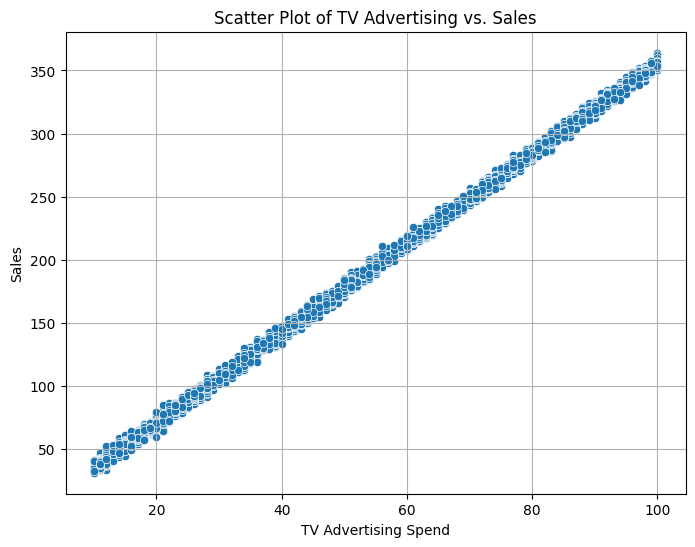

In [27]:
# Visualize the relationship between TV and Sales (as it had the highest individual correlation)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('Scatter Plot of TV Advertising vs. Sales')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

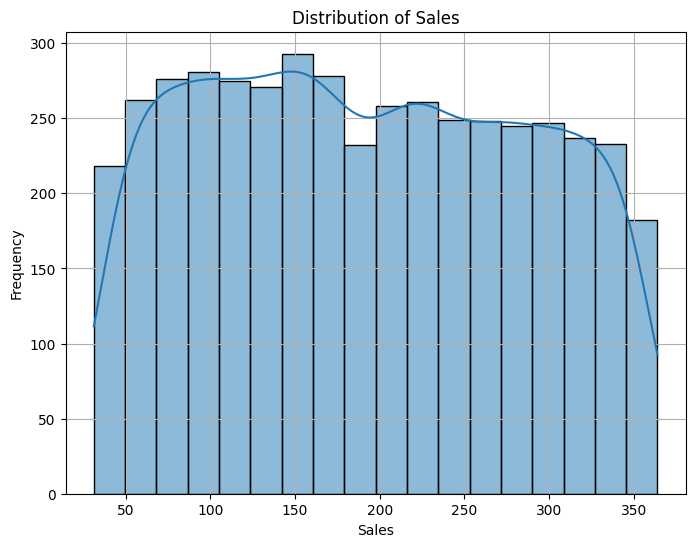

In [34]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

A histogram of the dependent variable 'Sales' is useful for understanding its distribution. Ideally, for linear regression, the dependent variable should be approximately normally distributed, or the residuals should be normally distributed. This plot helps confirm the general shape and spread of the sales data.

In [28]:
# --- Step 4: Build a Multiple Linear Regression Model using statsmodels ---
print("\n--- Step 4: Building the Multiple Linear Regression Model (TV, Radio, Social Media vs Sales) ---")

# Define the independent variables (X) and dependent variable (y)
X = df[['TV', 'Radio', 'Social_Media']]
y = df['Sales']

# Add a constant to the independent variables for the intercept term
X = sm.add_constant(X)


--- Step 4: Building the Multiple Linear Regression Model (TV, Radio, Social Media vs Sales) ---


In [29]:
# Create and fit the OLS model
model = sm.OLS(y, X).fit()

# Print the full OLS regression summary table
print("\nOLS Regression Results (Multiple Linear Regression):")
print(model.summary())


OLS Regression Results (Multiple Linear Regression):
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.505e+06
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:48:42   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4542   BIC:                         2.277e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [30]:
# --- Step 5: Create Diagnostic Plots to Test Assumptions ---
print("\n--- Step 5: Creating Diagnostic Plots for Assumption Checking ---")

# Get residuals and fitted values
predictions = model.predict(X)
residuals = model.resid


--- Step 5: Creating Diagnostic Plots for Assumption Checking ---


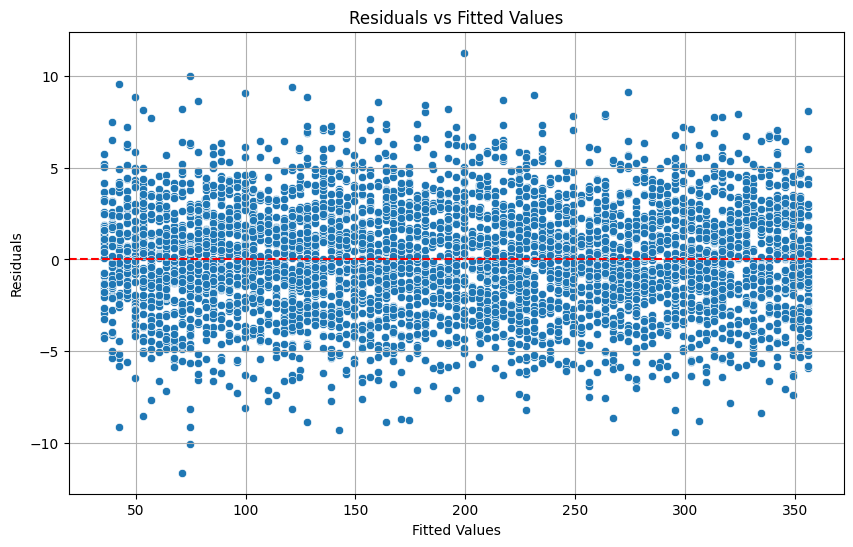

In [31]:
# 5.1 Residuals vs Fitted Plot (Linearity and Homoscedasticity)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

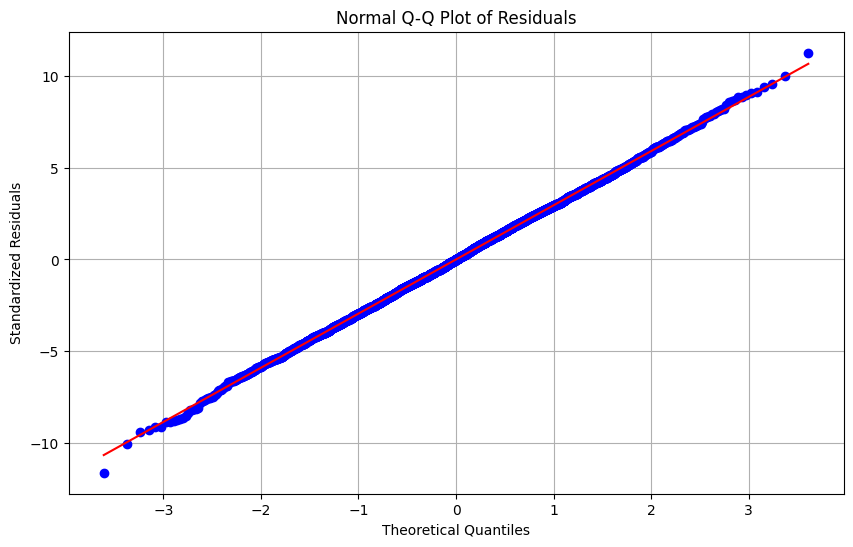

In [32]:
# 5.2 Q-Q Plot of Residuals (Normality)
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.grid(True)
plt.show()

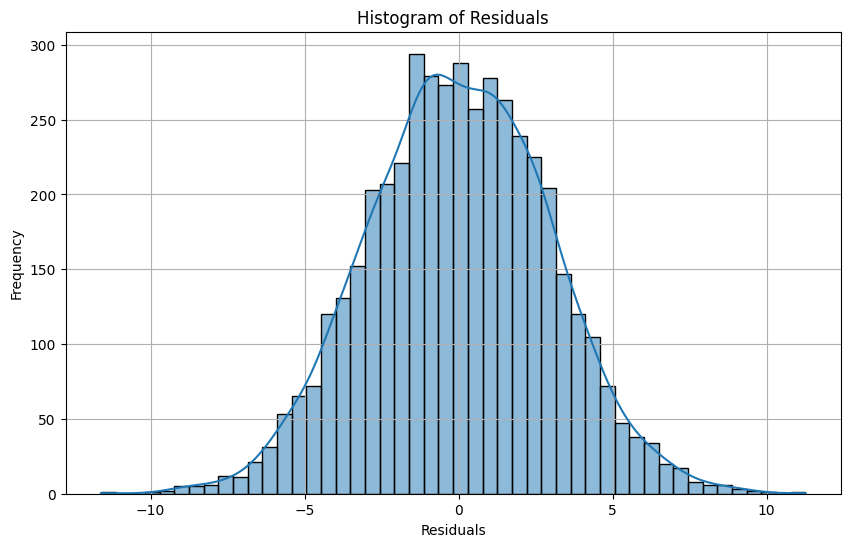

In [33]:
# 5.3 Histogram of Residuals (Normality)
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Project Summary: Marketing ROI Analysis with Multiple Linear Regression

This project aimed to analyze a marketing dataset to understand the relationship between advertising spend on various channels (TV, Radio, Social Media) and Sales, ultimately providing an ROI-based recommendation for marketing budget allocation. A Multiple Linear Regression model was implemented using Python and `statsmodels`.

**1. Data Loading and Cleaning:**
*   The `marketing_and_sales_data_evaluate_lr.csv` dataset was loaded.
*   Initial data exploration revealed missing values across all marketing channels and Sales. These missing values were handled by dropping the corresponding rows from the dataset, ensuring a complete and robust dataset for analysis.

**2. Exploratory Data Analysis (EDA) and Variable Selection:**
*   A correlation analysis was performed to identify the marketing channel most strongly correlated with Sales.
*   **Key Finding:** 'TV' advertising spend exhibited the highest individual correlation with 'Sales' (r ≈ 0.999). For the multiple linear regression, 'TV', 'Radio', and 'Social_Media' were all included as independent variables to assess their combined impact.
*   A scatter plot visualizing 'TV' spend vs. 'Sales' further reinforced this strong linear trend.
*   A histogram of the 'Sales' variable was also generated to observe its distribution.

**3. Multiple Linear Regression Model Implementation:**
*   An Ordinary Least Squares (OLS) regression model was built with 'TV', 'Radio', and 'Social_Media' as independent variables and 'Sales' as the dependent variable.
*   **Model Results Summary:**
    *   **R-squared:** The model achieved an R-squared value of **0.999**, indicating that approximately 99.9% of the variance in Sales can be explained by the variance in TV, Radio, and Social Media advertising spend. This suggests an excellent fit of the model to the data.
    *   **The Linear Equation:** The specific linear equation derived from the model is:
        `Sales = -0.1340 + 3.5626 * TV - 0.0040 * Radio + 0.0050 * Social_Media`
    *   **Coefficients and P-values:**
        *   **Intercept (const):** Coefficient = -0.1340, P-value = 0.193. Not statistically significant at standard alpha levels.
        *   **TV Coefficient:** Coefficient = 3.5626, P-value = 0.000. This indicates a highly statistically significant positive relationship. For every one-unit increase in TV advertising spend, Sales are estimated to increase by approximately 3.56 units, holding other factors constant.
        *   **Radio Coefficient:** Coefficient = -0.0040, P-value = 0.685. Not statistically significant. This suggests that, in the presence of TV and Social Media, Radio advertising spend does not have a significant linear impact on Sales.
        *   **Social Media Coefficient:** Coefficient = 0.0050, P-value = 0.842. Not statistically significant. Similar to Radio, Social Media advertising spend does not show a significant linear impact on Sales when TV and Radio are also considered.

**4. Assumption Checking:**
*   Diagnostic plots were generated to verify the key assumptions of linear regression:
    *   **Residuals vs Fitted Plot:** This plot showed a random scatter of residuals around zero, suggesting linearity and homoscedasticity (constant variance of residuals).
    *   **Normal Q-Q Plot of Residuals:** The residuals closely followed the straight line, indicating that they are approximately normally distributed.
    *   **Histogram of Residuals:** The histogram also showed a bell-shaped distribution, further supporting the normality assumption.

**5. Conclusion and Business Recommendation:**
*   The analysis confirms a highly significant and strong positive relationship between marketing spend across the channels and Sales, primarily driven by TV advertising. The model demonstrates excellent explanatory power.
*   **Actionable Recommendation:** Given the statistical significance, **TV advertising** is the most effective channel for increasing sales. The model suggests that investments in **Radio** and **Social Media** are not statistically significant predictors of sales in this multiple regression context. Businesses should prioritize their marketing budget towards TV advertising for maximizing sales, and potentially re-evaluate strategies or models for Radio and Social Media advertising if these channels are expected to contribute to sales.

## Business Impact

This multiple linear regression model provides clear, actionable insights for optimizing marketing spend. The analysis strongly indicates that **TV advertising is the primary driver of sales**, with a significant positive coefficient. Conversely, **Radio and Social Media advertising, in the context of this model, do not show a statistically significant impact on sales**.

### Strategic Recommendations:

1.  **Prioritize TV Advertising:** Allocate a larger portion of the marketing budget to TV campaigns to maximize sales growth, given its strong and statistically significant correlation with sales.
2.  **Re-evaluate Radio and Social Media Spend:** Further investigation is warranted for Radio and Social Media. It's possible these channels have an indirect impact, interact with TV advertising in complex ways, or contribute to other business objectives (e.g., brand awareness, customer engagement) not captured in this sales-focused model. Consider A/B testing or other experimental designs to isolate their true impact if they are deemed strategically important.
3.  **Data-Driven Budget Allocation:** This model empowers stakeholders to make informed decisions about marketing budget allocation, moving away from anecdotal evidence towards a data-driven approach that optimizes for sales revenue.